In [1]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

# Fetch the data.
df = pd.read_csv("https://ourworldindata.org/grapher/children-born-per-woman.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

# Fetch the metadata
metadata = requests.get("https://ourworldindata.org/grapher/children-born-per-woman.metadata.json?v=1&csvType=full&useColumnShortNames=true").json()

In [2]:
df.shape

(19402, 4)

In [3]:
mexico = df[df["entity"]=="Mexico"]
mexico.head()

,entity,code,year,fertility_rate_hist
11125,Mexico,MEX,1950,6.709
11126,Mexico,MEX,1951,6.727
11127,Mexico,MEX,1952,6.731
11128,Mexico,MEX,1953,6.734
11129,Mexico,MEX,1954,6.745


In [4]:
japon = df[df["entity"]=="Japan"]
japon.head()

,entity,code,year,fertility_rate_hist
8384,Japan,JPN,1947,4.614
8385,Japan,JPN,1948,4.463
8386,Japan,JPN,1949,4.373
8387,Japan,JPN,1950,3.615
8388,Japan,JPN,1951,3.225


In [5]:
anios_mexico = mexico['year'].to_numpy()
tasa_mexico = mexico['fertility_rate_hist'].to_numpy()

anios_japon = japon['year'].to_numpy()
tasa_japon = japon['fertility_rate_hist'].to_numpy()

In [6]:
promedio_japon = np.mean(tasa_japon)
maximo_japon = np.max(tasa_japon)
minimo_japon = np.min(tasa_japon)
desviacion_japon = np.std(tasa_japon)

promedio_mexico = np.mean(tasa_mexico)
maximo_mexico = np.max(tasa_mexico)
minimo_mexico = np.min(tasa_mexico)
desviacion_mexico = np.std(tasa_mexico)

In [7]:
print(promedio_japon)
print(maximo_japon)
print(minimo_japon)
print(desviacion_japon)
print()
print(promedio_mexico)
print(maximo_mexico)
print(minimo_mexico)
print(desviacion_mexico)

1.8388051948051947
4.614
1.208
0.7018619770141482

4.326364864864865
6.833
1.91
1.8802504834162772


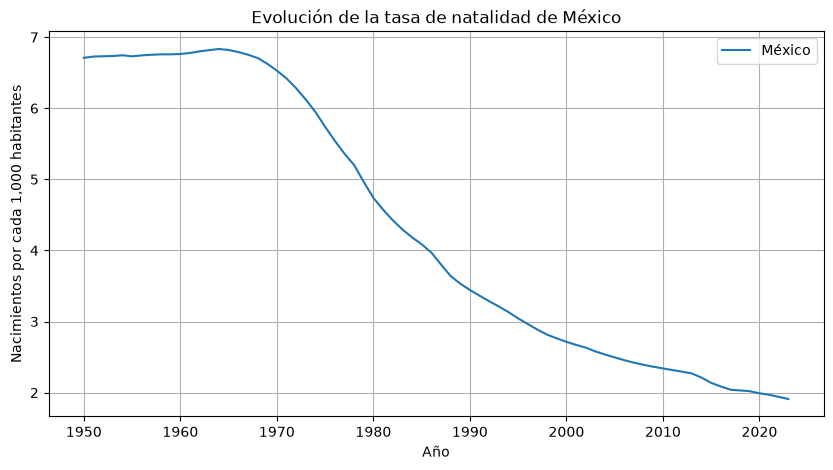

In [8]:
plt.figure(figsize = (10, 5))
plt.plot(
    anios_mexico,
    tasa_mexico,
    label="México"
)

plt.title("Evolución de la tasa de natalidad de México")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

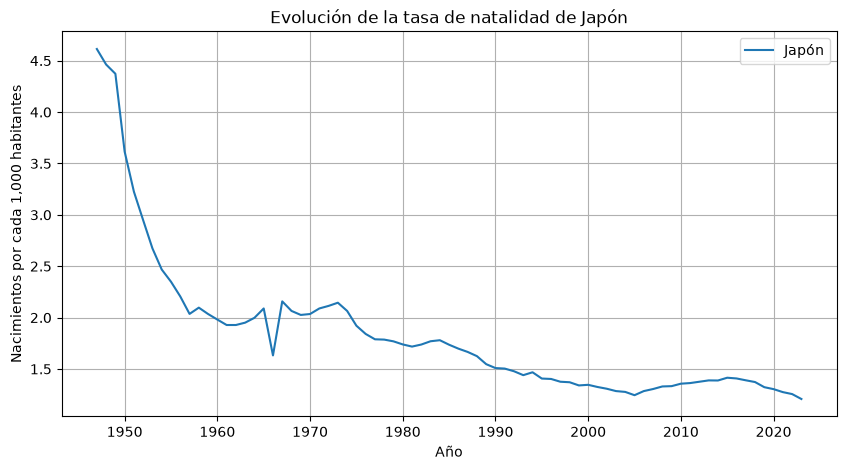

In [9]:
plt.figure(figsize = (10, 5))
plt.plot(
    anios_japon,
    tasa_japon,
    label="Japón"
)

plt.title("Evolución de la tasa de natalidad de Japón")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

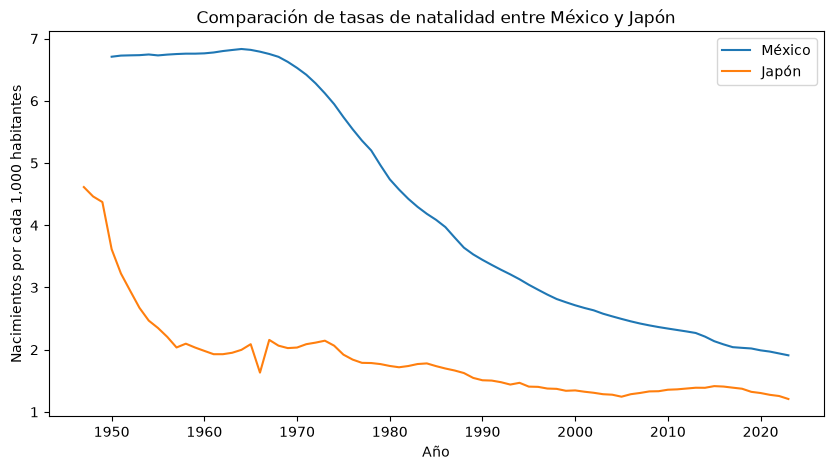

In [10]:
plt.figure(figsize = (10 , 5))

plt.plot(
    anios_mexico,
    tasa_mexico,
    label='México'
)

plt.plot(
    anios_japon,
    tasa_japon,
    label='Japón'
)

plt.xlabel('Año')
plt.ylabel('Nacimientos por cada 1,000 habitantes')
plt.title('Comparación de tasas de natalidad entre México y Japón')
plt.legend()
plt.show()

In [11]:
mexico.shape

(74, 4)

In [12]:
japon.shape

(77, 4)

In [14]:
mascara_coincidencia_anios = anios_japon >= anios_mexico.min()

In [15]:
mascara_coincidencia_anios.shape

(77,)

In [16]:
tasa_japon = tasa_japon[mascara_coincidencia_anios]
tasa_japon.shape

(74,)

In [17]:
anios_japon = anios_japon[mascara_coincidencia_anios]
anios_japon.shape

(74,)

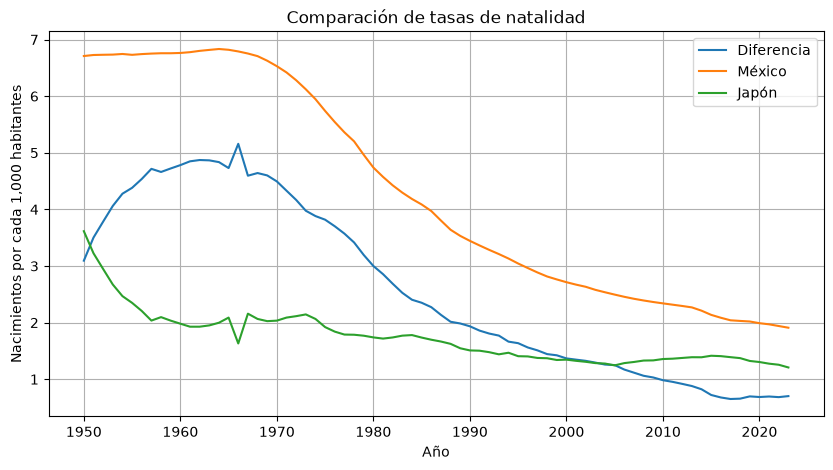

In [18]:
diferencia_mx_jpn = tasa_mexico - tasa_japon

plt.figure(figsize = (10 , 5))

plt.plot(
    anios_mexico,
    diferencia_mx_jpn,
    label='Diferencia'
)

plt.plot(
    anios_mexico,
    tasa_mexico,
    label='México'
)

plt.plot(
    anios_japon,
    tasa_japon,
    label='Japón'
)

plt.xlabel('Año')
plt.ylabel('Nacimientos por cada 1,000 habitantes')
plt.title('Comparación de tasas de natalidad')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
brazil = df[(df['entity'] == 'Brazil')]
brazil.head(10)

,entity,code,year,fertility_rate_hist
2371,Brazil,BRA,1950,6.122
2372,Brazil,BRA,1951,6.115
2373,Brazil,BRA,1952,6.102
2374,Brazil,BRA,1953,6.093
2375,Brazil,BRA,1954,6.087
2376,Brazil,BRA,1955,6.084
2377,Brazil,BRA,1956,6.083
2378,Brazil,BRA,1957,6.084
2379,Brazil,BRA,1958,6.083
2380,Brazil,BRA,1959,6.077


In [22]:
anios_brazil = brazil['year'].to_numpy()
tasa_brazil = brazil['fertility_rate_hist'].to_numpy()

In [23]:
diferencia_mx_brz = tasa_mexico - tasa_brazil

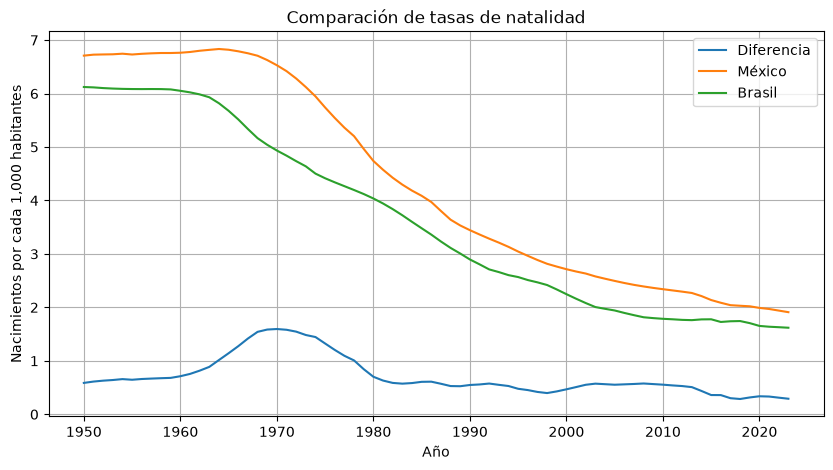

In [24]:
plt.figure(figsize = (10 , 5))

plt.plot(
    anios_mexico,
    diferencia_mx_brz,
    label='Diferencia'
)

plt.plot(
    anios_mexico,
    tasa_mexico,
    label='México'
)

plt.plot(
    anios_brazil,
    tasa_brazil,
    label='Brasil'
)

plt.xlabel('Año')
plt.ylabel('Nacimientos por cada 1,000 habitantes')
plt.title('Comparación de tasas de natalidad')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
anios_comunes = np.intersect1d(
    anios_mexico,
    anios_japon
)

In [26]:
anios_comunes

array([1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960,
       1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

### Otra forma de extraer los datos, es prepararlos desde pandas

In [27]:
#Otra forma de filtrar es con merge de pandas
comparacion_mexico_japon = pd.merge(
    mexico[["year", "fertility_rate_hist"]],
    japon[["year", "fertility_rate_hist"]],
    on="year",
    suffixes=("_mexico", "_japon")
)

In [28]:
comparacion_mexico_japon.head(3)

,year,fertility_rate_hist_mexico,fertility_rate_hist_japon
0,1950,6.709,3.615
1,1951,6.727,3.225
2,1952,6.731,2.947


In [ ]:
mexico_anios_comunes = mexico[mexico["year"].isin(anios_comunes)]
japon_anios_comunes = japon[japon["year"].isin(anios_comunes)]

In [ ]:
mexico_tasa_comunes = mexico_anios_comunes["fertility_rate_hist"].isin(anios_comunes)
japon_tasa_comunes = japon_anios_comunes["fertility_rate_hist"].isin(anios_comunes)

In [ ]:
anios_japon = np.delete(anios_japon, [23,25,30,42,48])

In [ ]:
plt.figure(figsize=(10,5))

In [ ]:
mex_anios_comunes = mexico_anios_comunes["year"].to_numpy()
jpn_anios_comunes = japon_anios_comunes["year"].to_numpy()

mex_tasa_comunes = mexico_anios_comunes["fertility_rate_hist"].to_numpy()
jpn_tasa_comunes = japon_anios_comunes["fertility_rate_hist"].to_numpy()